<a href="https://colab.research.google.com/github/cchan555/lis4693/blob/main/lab-4/ChanLab4Mar102026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)
Training set has 3900 samples.
Testing set has 1672 samples.
Preprocessing training data...
Preprocessing test data...
Training Naive Bayes classifier...
Training Logistic Regression classifier...
Training Random Forest classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


NB Accuracy: 0.9629186602870813
LR Accuracy: 0.97188995215311
RF Accuracy: 0.9778708133971292
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1448
        spam       1.00      0.72      0.84       224

    accuracy                           0.96      1672
   macro avg       0.98      0.86      0.91      1672
weighted avg       0.96      0.96      0.96      1672

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98      1448
        spam       0.99      0.80      0.88       224

    accuracy                           0.97      1672
   macro avg       0.98      0.90      0.93      1672
weighted avg       0.97      0.97      0.97      1672

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1448
        spam       1.00      0.83      0.91       224

    accuracy                           0.98      1672
   macro avg       0.99      0.92 

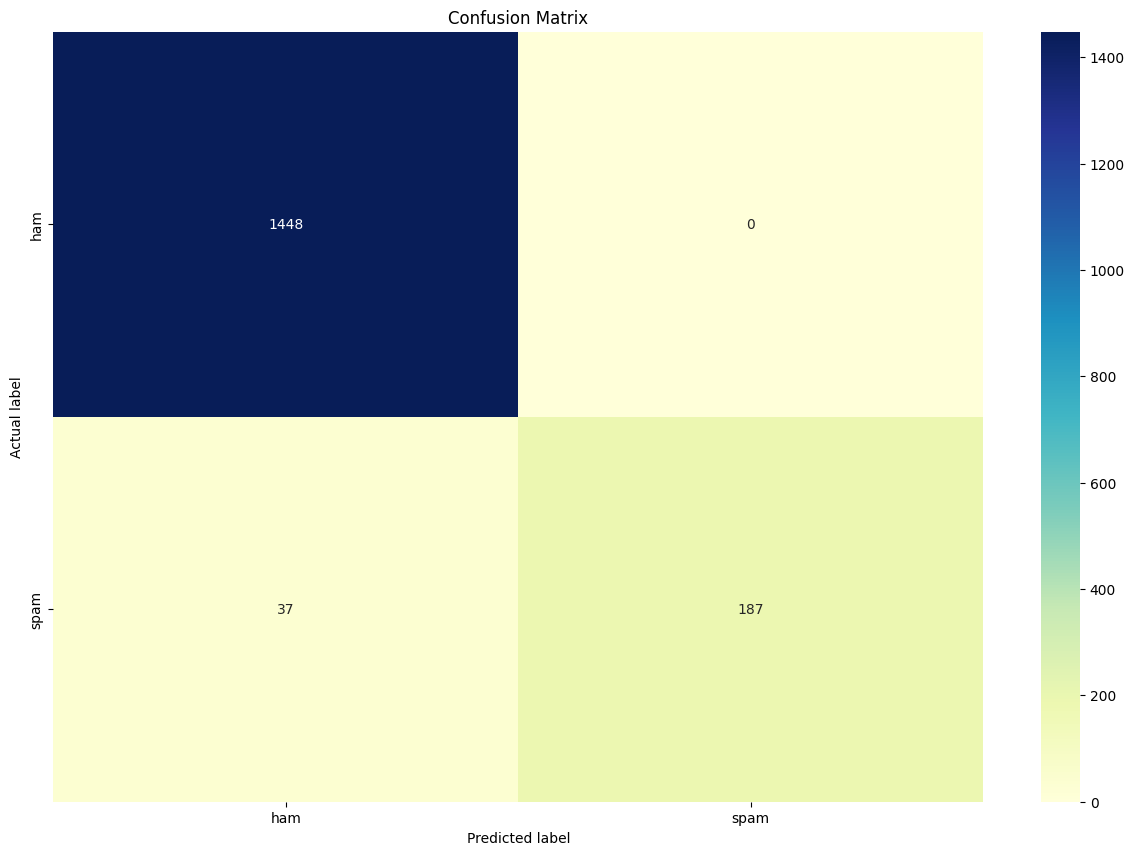

                                             message  label
0  Free entry to win a £1000 cash prize! Text WIN...    NaN
1  Congratulations! You have been selected for a ...    NaN
2  URGENT: Your account has been compromised. Cal...    NaN
3        Can you pick up some milk on your way home?    NaN
4  You have won a free vacation to the Bahamas! R...    NaN
(91, 2)
                                             message label
0  Free entry to win a £1000 cash prize! Text WIN...  spam
1  Congratulations! You have been selected for a ...   ham
2  URGENT: Your account has been compromised. Cal...   ham
3        Can you pick up some milk on your way home?   ham
4  You have won a free vacation to the Bahamas! R...  spam
5  FREE MSG: You are entitled to a free ringtone....   ham
6  WINNER! You have been chosen to receive a £500...   ham
7              Are you free this weekend for a hike?   ham
8  Claim your free prize now! Limited time offer....  spam
9    Don't forget about the meeting tomorr

In [ ]:
# Cody Chan
# Lab 4 - Supervised Machine Learning

#
# Task 1: Load assigned Dataset and determine text data and target labels
#
!pip install scikit-learn

import requests
import io
import pandas as pd

url = "https://raw.githubusercontent.com/cchan555/lis4693/refs/heads/main/lab-4/sms%2Bspam%2Bcollection/SMSSpamCollection"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

df = pd.read_csv(io.StringIO(text),
                 sep = '\t', # Tab separation
                 header = None,
                 names = ['label', 'message']) # Add names for each columns
print(df.head()) # Print the first 5 rows od dataset
print(df.shape) # Print the number of rows and columns

# Explaination in text block below

#
# Task 2: Split data into 70:30 ratio and perform text preprocessing
#
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# Define features and target
features = df['message']
target = df['label']

# Define label for reporting
target_names = ['ham', 'spam']

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('') # Replace NaN with empty string
X_test = X_test.fillna('') # Replace NaN with empty string

# Build preprocessing pipeline
preprocessing = Pipeline([
    ('vect', CountVectorizer()), # Convert raw text into a matrix of word counts
    ('tfidf', TfidfTransformer()) # Scale words to make unique
])

# Fit pipeline on training data and transform it
print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

# Only transform test data
print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

#
# Task 3: Train 3 classifiers of choice using training data.
# Evaluate and compare the performance using metrics such as
# accuracy, precision, recall, and F1- Score.
#

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

# Classifier 1: Naive Bayes
nb_classifier = MultinomialNB()
print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)
nb_predictions = nb_classifier.predict(test_preprocessed)

# Classifier 2: Logistic Regression
lr_classifier = LogisticRegression(multi_class="ovr")
print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)
lr_predictions = lr_classifier.predict(test_preprocessed)

# Classifier 3: Random Forest
random_classifier = RandomForestClassifier()
print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)
random_predictions = random_classifier.predict(test_preprocessed)

# Finding all 3 classifiers using accuracy
import numpy as np
print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

# Detailed evaluation
from sklearn.metrics import classification_report  # Import classification_report
print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, lr_predictions, target_names=target_names))
print(classification_report(y_test, random_predictions, target_names=target_names))

# Confusion Matrix
import seaborn as sn
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

best_prediction = random_predictions
best_classifier = random_classifier

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, best_prediction)
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index = ['ham', 'spam'],
    columns = ['ham', 'spam'])
plt.figure(figsize=(15, 10))
x = sn.heatmap(
    conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(),
    fmt='d', cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

# Explanation in text block below

#
# Task 4: Generate pseudo CSV dataset with atleast 100 rows.
#

# Load in LLM pseudo dataset
pseudo_url = "https://raw.githubusercontent.com/cchan555/lis4693/refs/heads/main/lab-4/pseudo_sms.csv"
pseudo_response = requests.get(pseudo_url)
pseudo_response.raise_for_status()
pseudo_df = pd.read_csv(io.StringIO(pseudo_response.text),
                        quotechar = '"',
                        on_bad_lines = 'skip')
print(pseudo_df.head()) # Print the first 5 rows of dataset
print(pseudo_df.shape) # Print the number of rows and columns

# Preprocess pseudo dataset
pseudo_df['message'] = pseudo_df['message'].fillna('')
pseudo_preprocessed = preprocessing.transform(pseudo_df['message'])

# Predict label
pseudo_predictions = best_classifier.predict(pseudo_preprocessed)

# Add predictions to pseudo dataset
pseudo_df['label'] = pseudo_predictions
print(pseudo_df[['message', 'label']].head(10))
print(pseudo_df['label'].value_counts())

# Create and save Dataframe as CSV
pseudo_df.to_csv('predicted.csv', index=False)



# Explanations: <br>
Task 1: Briefly explain the rationale for choosing these columns and how they will be used in the classification process. <br>
>
For this dataset, the 'message' label contains raw SMS text that the classifiers will learn from. Each message has some pattern, especially spam messages. They often have some kind of urgent message or special offer. The 'label' indicates whether the message is genuine or a spam message. During the classification process, the text messages will be converted to numerical vectors using CountVectorizer and TF-IDF transformation, which will allow us to see the amount of times something unique occurs across all messages. Later, they will be used to train the classifiers to predict the label for new messages.

Task 3: Briefly summarize your findings and explain which model performed best and why. Also, explain the reuslts in your own words. Interpret what the values in the matric represent in terms of correct and incorrect classifications. <br>
>
All the classifiers performed well in this dataset, however, Random Forest analysis scored the highest accuracy with 97.8%. Naive Bayes method scored the lowest out of the three, with 96.3% accuracy, and Logistic Regression scored 97.2% accuracy. Observing the other scores, specifically the F1-score under the spam category, the Random Forest scored the highest at 0.91 compared to the other two methods used. It is probably because it combines multiple decision trees to observe more complex word patterns in messages, which helps with analyzing spam detection. <br>

For the confusion matrix, it has four quadrants: the top left is for ham messages that are ham, the top right is for ham incorrectly predicted as spam, the bottom left is for spam messages incorrectly predicted as ham, and the bottom right is for spam messages correctly predicted as mspam. The random forest model has a very high count for correct predictions of legitimate messages, and it relatively identifies spam messages correctly as well. The issue with this model is that it has a few identifications of spam messages being classified as ham, which is about a 0.83 score.

Task 4: Report how many were correctly classified and how many were misclassified, and briefly share your insights about the model’s performance. <br>
>
Through manual review, it can be observed that there were some misidentifications. Currently, there are 2 out of 10 labeled as spam, however, in the CSV file, rows 1, 2, 5, and 6 are clearly spam messages that did not get picked up by the model. It seems that the model struggles with seeing high urgency messages or congratulatory related messages. For example, high urgency words or congratulatory related messages, like “Congratulations!”, “URGENT”, “FREE MSG”, and “WINNER!”. Overall, this model is fairly accurate as it can identify 70 legitimate messages and 21 spam messages that total to 91 total messages.


Task 5: Brief Reflection <br>
>
What went well? <br>
While going through this lab, it was helpful to have a lot of files and information about this topic. I was able to fully understand the topic of machine learning and how it can be applied to applications. The readings for this lab looked very dense, but they were so helpful to my success.

What did not go well or what challenges you encourtered? <br>
The main challenge I had while working on this lab was loading in the dataset and creating the pseudo CSV dataset. While I was loading in the dataset, I ran into issues that I have not seen before. I realized that the dataset I was assigned was not a CSV file, so I had to put in new parameters/restrictions while reading in the data. I needed to add tab separations, and I created two names for the two columns. When creating the pseudo CSV dataset and reading it in, recieved errors and needed to read in and skip certain lines in order for the program to run.